# Frost's hybrid decision list model with convergence guarantee plot generation

## Imports

In [26]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
from itertools import product
import numpy as np
import pandas as pd
from pandas.io.parsers import read_csv
from hybrids import max_pareto_front
import matplotlib.pyplot as plt
from hybrids import hyb_rules_frost, categorize_numericals
import multiprocessing as mp
from sklearn.metrics import auc
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
blackbox = 'rf'  # Random forest
# blackbox = 'ab'  # AdaBoosted decision trees
# blackbox = 'xg'  # XGboost (gbtree)

In [14]:
path = './datasets/census/'; name = 'census'

# path = './datasets/coupon/'; name = 'coupon'

# path = './datasets/stop&frisk/'; name = 'stop-and-frisk'

### Data reading

In [15]:
# read data
Xtrain = read_csv(path + 'train.csv',header = 0, sep = ',')
Xtest = read_csv(path + 'test.csv',header = 0, sep = ',')
bbm = read_csv(path + blackbox + '_ybtrain.csv',header = 0,sep = ',')
Ybtrain = np.array(bbm['Yb'])
bbm = read_csv(path + blackbox + '_ybtest.csv',header = 0,sep = ',')
Ybtest = np.array(bbm['Yb'])
# Seperate Y (answers) from dataframe
Ytrain = Xtrain['Y'].to_numpy()
Xtrain.drop(['Y'], axis = 1, inplace = True) 
Ytest = Xtest['Y'].to_numpy()
Xtest.drop(['Y'], axis = 1, inplace = True) 

ntrain = Xtrain.shape[0]
(Xtrain, Xtest) = categorize_numericals(Xtrain, df_test=Xtest)
Ytrain_majority = np.bincount(Ytrain).argmax()
bad_Ybtest = np.full_like(Ybtest, Ytrain_majority)

### Train, predict and produce result

In [ ]:
results = []
test_num = len(Ytest)

l_choices = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
s_choices = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

def fit_yield(tup):
    (l, s_choices) = tup
    result = []
    model = hyb_rules_frost()
    iterator = model.fit_yield(Xtrain,Ytrain, l, s_choices, 3)
    for _ in iterator:
        Yhat, covered = model.predict(Xtest, Ybtest)
        covered_amount = len(covered)
        correct_amount = np.count_nonzero(Yhat == Ytest)
    
        transparency = covered_amount / test_num
        accuracy = correct_amount / test_num

        result.append( {
            'l': model.l,
            's': model.s,
            'transparency': transparency,
            'accuracy': accuracy,
            'amount_conditions': model.conditions 
        })
    return result


def fit_bad(tup):
    # "bad" refers to the "interpretable black-box model" that always predicts majority target value in training set
    (l, s_choices) = tup
    result = []
    model = hyb_rules_frost()
    iterator = model.fit_yield(Xtrain,Ytrain, l, s_choices)
    for _ in iterator:
        Yhat, covered = model.predict(Xtest, bad_Ybtest)
        correct_amount = np.count_nonzero(Yhat == Ytest)
    
        accuracy = correct_amount / test_num

        result.append( {
            'l': model.l,
            's': model.s,
            'transparency': 1.0,
            'accuracy': accuracy,
            'amount_conditions': model.conditions 
        })
    return result


params = product(l_choices, [s_choices])
bad_params = product(l_choices, [[1.0,],])

ctx = mp.get_context("fork")   
with ctx.Pool(4) as pool:
    results = pool.map(fit_yield, params)
    results.extend(pool.map(fit_bad, bad_params))
results = [
    x
    for xs in results
        for x in xs
]

# Save as csv
results_df = pd.DataFrame(results)
# results_df.to_csv(path + f"{name}_{blackbox}_hybdecisionlist_results.csv", index=False)

### Plot generation

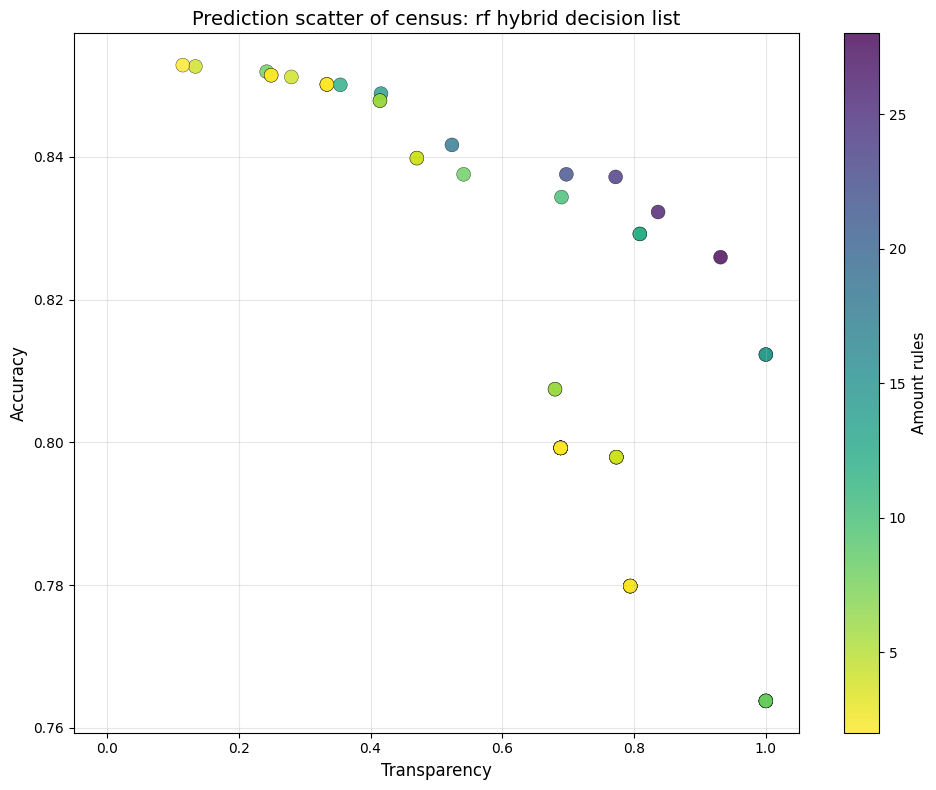

In [22]:
# Create the plot
plt.figure(figsize=(10, 8))

amount_rules_vals = [result['amount_conditions'] for result in results]
transparency_vals = [result['transparency'] for result in results]
accuracy_vals = [result['accuracy'] for result in results]

scatter = plt.scatter(
    transparency_vals,
    accuracy_vals,
    c=amount_rules_vals,
    cmap='viridis_r',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3,
 )

cbar = plt.colorbar(scatter)
cbar.set_label('Amount rules', fontsize=11)

plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Prediction scatter of {name}: {blackbox} hybrid decision list', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybdecisionlist_scatter.svg')
plt.show()

#### Pareto front

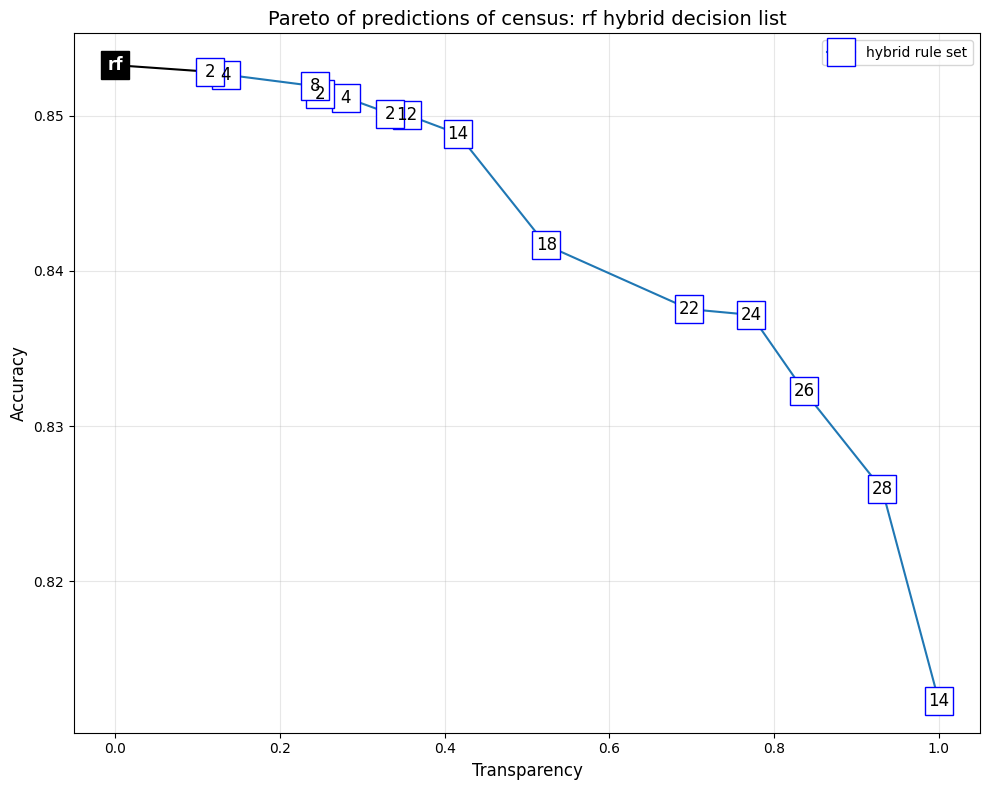

In [25]:
maxpf_df = max_pareto_front(results_df, "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid rule set")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["amount_conditions"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid decision list', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybdecisionlist_pareto.svg')
plt.show()

## Colerful AUTAC (area under the accuracy-transparency trade-off curve) bar

AUTAC with conditions$\leq2$: 0.6603554736423958
AUTAC with conditions$\leq10$: 0.827195495775186
AUTAC with conditions$\leq20$: 0.8401325013493274
AUTAC with conditions$\leq30$: 0.8423261912873211
AUTAC with conditions$\leq40$: 0.8423261912873211
AUTAC with conditions$\leq50$: 0.8423261912873211
AUTAC with conditions$\leq60$: 0.8423261912873211
AUTAC with conditions$\leq70$: 0.8423261912873211
AUTAC with conditions$\leq80$: 0.8423261912873211
AUTAC with conditions$\leq90$: 0.8423261912873211
AUTAC with conditions$\leq100$: 0.8423261912873211
AUTAC with No restriction: 0.8423261912873211


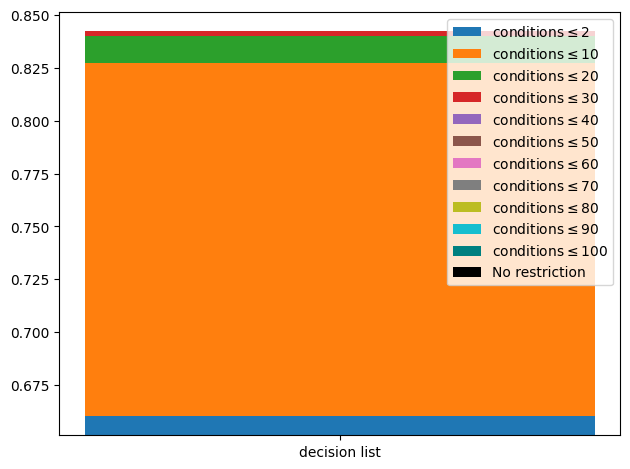

In [28]:
def get_autacs(th):
    pareto_df = max_pareto_front(
        (results_df[results_df["amount_conditions"] <= th]) if th != None else results_df, "transparency", "accuracy"
    ).sort_values("transparency", ascending=False, ignore_index=True)
    pareto_df.loc[len(pareto_df)] = {
        "offload_thrs": 0,
        "transparency": 0,
        "accuracy": pareto_df["accuracy"].iloc[-1],
        "amount_conditions": pareto_df["amount_conditions"].iloc[-1],
    }
    return auc(pareto_df["transparency"], pareto_df["accuracy"])

ax = plt.gca()


feature_filter_list = [2] + list(range(10, 101, 10)) + [None]
autacs = [get_autacs(th) for th in feature_filter_list]
labels = [f"conditions$\\leq{th}$" if th is not None else "No restriction" for th in feature_filter_list]
colors = [f"C{i}" for i in range(10)] + ["teal", "black"]

au_max = max(autacs)
au_min = min(autacs)
margin = (au_max - au_min) * 0.05
range_min = au_min - margin
range_max = au_max + margin

for idx, autac in enumerate(autacs):
    print(f"AUTAC with {labels[idx]}:",autac)
    ax.bar(
        [f"decision list"], 
        autac, label=labels[idx], 
        color=colors[idx], 
        zorder=-idx
        )
ax.set_ylim(range_min, range_max)
plt.tight_layout()
plt.legend()
plt.show()